#**Problem Set IV - Mecánica Celeste:**

<div align="left">

### Juliana Ruiz Montoya
### 1007435437

**NOTA:** En este Notebook se realizarán computacionalmente los punto 3, el iteral b y del punto 8 los iterales c, d y e

In [1]:
!pip install -Uq pymcel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.6/997.6 kB 15.5 MB/s eta 0:00:00


In [2]:
# Librerías

import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import matplotlib.animation as animation

pymcel version  0.6.24


### **3. Péndulo doble.**

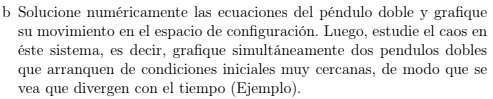

Espacio de configuración del péndulo simple:

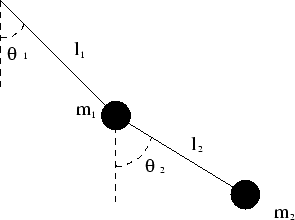

Las variables generalizadas de este problema corresponden a los ángulos $\theta_1$ que describe el movimiento del primer péndulo y $\theta_2$ que describe el movimiento ligado del segundo péndulo.

  Estas dos variables son convenientes para resolver el problema apropiadamente por el método del lagrangiano, ya que al ser ángulos pueden describir los movimientos que tienden a trazar trayectorias circulares que se describen mejor en las coordenadas polares, lo que simplifica las ecuaciones de movimiento, así mismo las formulaciones de las energías cinética y potencial; por tanto, facilitan en si el análisis del problema.

Se define la función `pendulo_doble(Ys,t,l1,l2,m1,m2)`, la cual linealiza las ecuaciones diferenciales que describe el sistema, la cual recibe el vector de las condiciones iniciales, el tiempo de integración, las longitudes de las cuerdas y la masas de las particulas y retorna las velocidades y las aceleraciones.



In [3]:
def pendulo_doble(Ys,t,l1,l2,m1,m2):
  g = 9.81 #m/s

  # Se convierte el vector Ys en variables del sistema
  q1,q2 = Ys[:2]
  v1,v2 = Ys[2:]

  #Se definen las ecuaciones diferenciales
  dq1dt = v1
  dq2dt = v2

  dv1dt = (-g*np.sin(q1)*(2*m1 + m2) - m2*g*np.sin(q1 - 2*q2) - (2*m2*np.sin(q1 - q2))*(l1*v1**2*np.cos(q1 - q2) + l2*v2**2))/(l1*(2*m1 - m2*np.cos(2*q1 - 2*q2) + m2))
  dv2dt = ((2*np.sin(q1 - q2))*((v1**2)*l1*(m1 + m2) + g*(m1 + m2)*np.cos(q1) + (v2**2)*l2*m2*np.cos(q1 - q2)))/(l2*(2*m1 - m2*np.cos(2*q1 - 2*q2) + m2))

  return [dq1dt, dq2dt, dv1dt, dv2dt]


Se propone un sistema en donde la longitudes de las cuerdas son de $l_1 = l_2 = 1 m $, las masas $m_1 = m_2 = 1 kg $, los ángulos iniciales los cuales empezarán a oscilar los péndulos $\theta_1 = \frac{\pi}{2}$ y $\theta_2 = \frac{\pi}{4}$ y sus velocidades angulares $\omega_1 = \omega_2 = 0.5 $



In [4]:
#Se define el tiempo de integración
ts = np.linspace(0, 10, 500)

#Se definen los ángulos
theta_1 = np.pi/2
theta_2 = np.pi/4

#Se definen las velocidades angulares iniciales
w1 = 0.5
w2 = 0.5

#Se define el vector de las condiciones iniciales
Ys0 = [theta_1, theta_2, w1, w2]

#Se definen los parámetros físicos del sistema
l1 = 1.0
l2 = 1.0
m1 = 1.0
m2 = 1.0

Se evoluciona el sistema con ayuda de la función odeint la cual recibe la función

In [5]:
solucion = odeint(pendulo_doble, Ys0, ts, args = (l1,l2,m1,m2))
Theta_1 = solucion[:,0]
Theta_2 = solucion[:,1]

Se realiza un gráfico para ver la evolución del ángulo del primer péndulo en un tiempo de 10 segundos

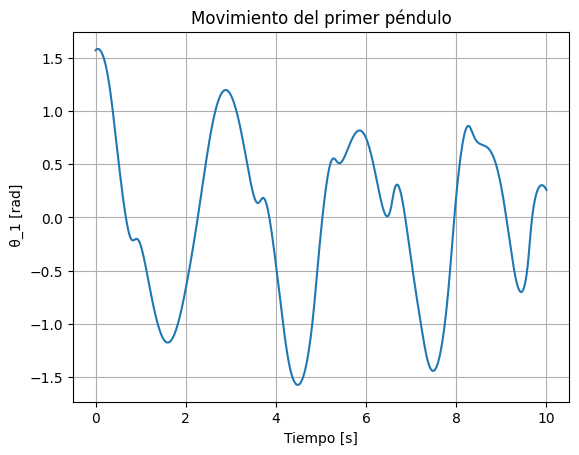

In [6]:
plt.plot(ts,Theta_1)
plt.title('Movimiento del primer péndulo')
plt.xlabel('Tiempo [s]')
plt.ylabel(' θ_1 [rad]')
plt.grid()

Como se puede ver en el gráfico, el péndulo tiende a tener un comportamiento periodico, sin embargo este se ve afectado por el movimiento del otro péndulo al estar ligados.

Se realiza un gráfico para ver la evolución del ángulo del segundo péndulo en un tiempo de 10 segundos

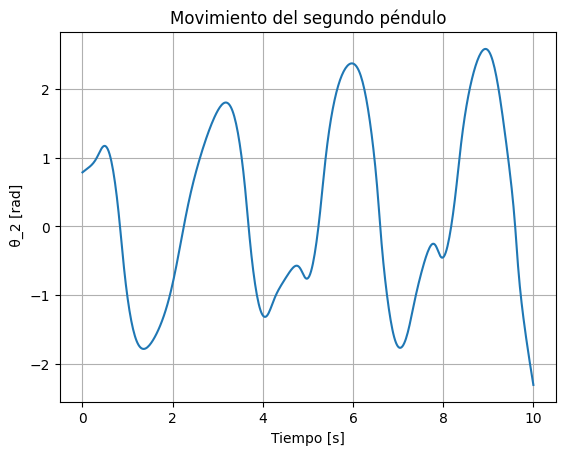

In [7]:
plt.plot(ts,Theta_2)
plt.title('Movimiento del segundo péndulo')
plt.xlabel('Tiempo [s]')
plt.ylabel(' θ_2 [rad]')
plt.grid()

Como se muestra en el gráfico este segundo péndulo alcanza ángulos mayores que el primero, es decir que tiene un movimiento tambien que tiende a ser periodico, pero que se ve afectado por el movimiento del primer péndulo, por lo que describe una trayectoria un poco más caótica que el primero.

Se hace la transformación a las coordenadas del espacio normal

In [8]:
#Posiciones del primer péndulo
x1 = l1*np.sin(Theta_1)
y1 = -l1*np.cos(Theta_1)

#Posiciones del segundo péndulo
x2 = x1 + l2*np.sin(Theta_2)
y2 = y1 - l2*np.cos(Theta_2)

Gráfico que muestra la trayectoria del péndulo doble a partir de sus coordenadas $x$ y $y$

(np.float64(-2.1147819791714317),
 np.float64(2.122954510160125),
 np.float64(-2.0990071981460376),
 np.float64(0.11649504393056352))

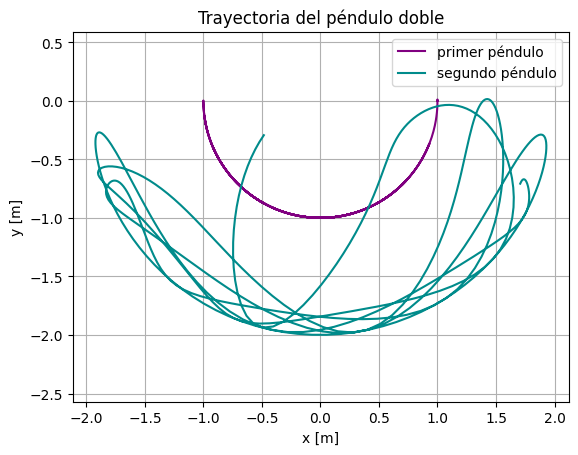

In [9]:
plt.plot(x1,y1, color='purple', label = 'primer péndulo')
plt.plot(x2,y2, color='darkcyan', label = 'segundo péndulo')
plt.title('Trayectoria del péndulo doble')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.grid()
plt.legend()
plt.axis('equal')

Luego de ver la trayectoria de un péndulo doble, se estudia el efecto de la variación mínima de las condiciones iniciales para generar caos entre dos pendulos simples.

Se establecen las condiciones iniciales del segundo péndulo doble.

In [10]:
# Condiciones iniciales con pequeña perturbación (segundo péndulo)
delta = 0.1
Ys0_perturbado = [theta_1 + delta, theta_2 + delta, w1 + delta, w2 + delta]

In [11]:
# Resolver la ecuación diferencial
solucion_perturbada = odeint(pendulo_doble, Ys0_perturbado, ts, args=(l1, l2, m1, m2))

Theta_1_perturbado = solucion_perturbada[:, 0]
Theta_2_perturbado = solucion_perturbada[:, 1]

In [12]:
# Posiciones del segundo péndulo perturbado
x1_p = l1 * np.sin(Theta_1_perturbado)
y1_p = -l1 * np.cos(Theta_1_perturbado)

x2_p = x1_p + l2 * np.sin(Theta_2_perturbado)
y2_p = y1_p - l2 * np.cos(Theta_2_perturbado)

(np.float64(-2.182271554720181),
 np.float64(2.1819865236656426),
 np.float64(-2.105386968027647),
 np.float64(0.22430646482759037))

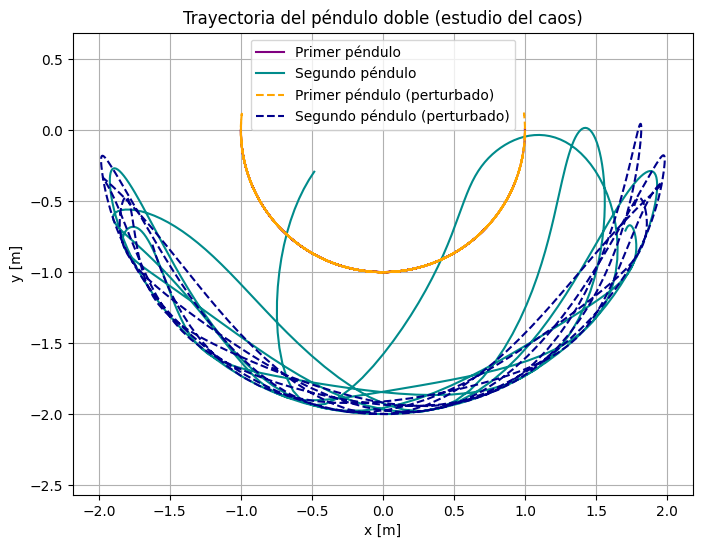

In [13]:
# Graficar la trayectoria de ambos péndulos
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, color='purple', label='Primer péndulo')
plt.plot(x2, y2, color='darkcyan', label='Segundo péndulo')
plt.plot(x1_p, y1_p, color='orange', linestyle='--', label='Primer péndulo (perturbado)') # Changed lineStyles to linestyle
plt.plot(x2_p, y2_p,color='darkblue', linestyle='--', label='Segundo péndulo (perturbado)') # Changed lineStyles to linestyle
plt.title('Trayectoria del péndulo doble (estudio del caos)')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.legend()
plt.grid()
plt.axis('equal')

### **Conclusión**

El comportamiento del segundo péndulo doble, con una pequeña variación en sus condiciones iniciales, nos muestra un ejemplo claro de sensibilidad a las condiciones iniciales, una característica fundamental de los sistemas caóticos. A partir de la simulación, podemos concluir lo siguiente:

- **Divergencia exponencial:** Aunque ambos péndulos comienzan con condiciones casi idénticas, sus trayectorias divergen con el tiempo. Al principio, las diferencias son imperceptibles, pero a medida que el sistema evoluciona, los dos péndulos toman caminos completamente distintos.

- **Dependencia extrema de los parámetros:** El péndulo doble es un sistema no lineal, lo que significa que los efectos de una pequeña perturbación no son proporcionales a la perturbación misma. Un cambio diminuto en las condiciones iniciales no genera solo una pequeña variación en la trayectoria, sino una desviación drástica con el tiempo.

### **8. El Hamiltoniano de Hénon-Heiles.**

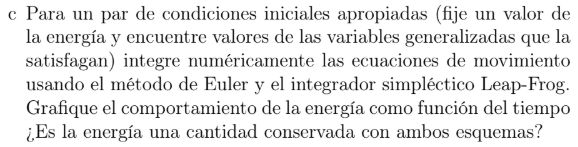

Para resolver este punto, primero se realizan funciones para plantear el Hamiltoniano y las ecuaciones de Hamilton.

El Hamiltoniano describe la energía total del sistema, que es la suma de la energía cinética y potencial. Se define como:

\begin{equation}
H = \frac{p_x^2}{2m} + \frac{p_y^2}{2m} + \frac{1}{2} (x^2 + y^2) + xy - \frac{1}{3} y^3
\end{equation}

Este Hamiltoniano corresponde al sistema de Hénon-Heiles, un sistema no lineal usado en estudios de dinámica caótica.

Las ecuaciones de Hamilton describen la evolución del sistema en el tiempo:

\begin{equation}
\dot{x} = \frac{\partial H}{\partial p_x}, \quad \dot{y} = \frac{\partial H}{\partial p_y}
\end{equation}
\begin{equation}
\dot{p_x} = -\frac{\partial H}{\partial x}, \quad \dot{p_y} = -\frac{\partial H}{\partial y}
\end{equation}

In [21]:
def hamiltoniano(x, y, px, py, m=1.0):
    """Calcula el Hamiltoniano del sistema de Hénon-Heiles."""
    return (px**2 + py**2) / (2 * m) + 0.5 * (x**2 + y**2) + x * y - (1/3) * y**3

def ecuaciones_hamilton(x, y, px, py, m=1.0):
    """Calcula las ecuaciones de Hamilton del sistema."""
    return px / m, py / m, -x - 2 * x * y, y**2 - x**2 - y

**Método de integración de Euler.**

El método de Euler usa la aproximación:

\begin{equation}
q(t + dt) \approx q(t) + \dot{q} \cdot dt
\end{equation}

\begin{equation}
p(t + dt) \approx p(t) + \dot{p} \cdot dt
\end{equation}

Es un método explícito de primer orden, pero puede acumular errores numéricos rápidamente.

**Método de integración Leap-Frog (Verlet)**

El método Leap-Frog es más estable que Euler y conserva mejor la energía en sistemas hamiltonianos.

1. Se actualizan los momentos a la mitad del paso de tiempo.

2. Se actualizan las posiciones con estos valores intermedios.

3. Se recalculan las fuerzas y se finaliza la actualización de los momentos.



In [22]:
def euler_step(x, y, px, py, dt, m=1.0):
    """Método de integración de Euler."""
    dxdt, dydt, dpxdt, dpydt = ecuaciones_hamilton(x, y, px, py, m)
    return x + dxdt * dt, y + dydt * dt, px + dpxdt * dt, py + dpydt * dt

def leap_frog_step(x, y, px, py, dt, m=1.0):
    """Método de integración de Leap-Frog."""
    dxdt, dydt, dpxdt, dpydt = ecuaciones_hamilton(x, y, px, py, m)
    px_half, py_half = px + 0.5 * dpxdt * dt, py + 0.5 * dpydt * dt
    x_new, y_new = x + px_half * dt / m, y + py_half * dt / m
    _, _, dpxdt_new, dpydt_new = ecuaciones_hamilton(x_new, y_new, px_half, py_half, m)
    px_new, py_new = px_half + 0.5 * dpxdt_new * dt, py_half + 0.5 * dpydt_new * dt
    return x_new, y_new, px_new, py_new

Se establecen los valores iniciales para $x$, $y$, $p_x$, $p_y$, el número de pasos y el tamaño del paso de integración $dt$.

In [23]:
m = 1.0
x0, y0 = 0.0, 0.1
px0, py0 = 0.1, 0.0
dt = 0.01
n_pasos = 10000

Se estbalece una función que realiza la integración de cada método.

In [24]:
def integrar(n_pasos, dt, metodo, x0, y0, px0, py0, m=1.0):
    """Realiza la integración numérica utilizando el método especificado."""
    x, y, px, py = [x0], [y0], [px0], [py0]
    for _ in range(n_pasos):
        x_, y_, px_, py_ = metodo(x[-1], y[-1], px[-1], py[-1], dt, m)
        x.append(x_)
        y.append(y_)
        px.append(px_)
        py.append(py_)
    return np.array(x), np.array(y), np.array(px), np.array(py)

In [25]:
# Integración con ambos métodos
x_euler, y_euler, px_euler, py_euler = integrar(n_pasos, dt, euler_step, x0, y0, px0, py0, m)
x_lf, y_lf, px_lf, py_lf = integrar(n_pasos, dt, leap_frog_step, x0, y0, px0, py0, m)

# Cálculo de la energía
E_euler, E_lf = hamiltoniano(x_euler, y_euler, px_euler, py_euler, m), hamiltoniano(x_lf, y_lf, px_lf, py_lf, m)

Se comparan las trayectorias obtenidas con ambos métodos.

In [35]:
def graficar_energia(E_euler, E_lf, dt, n_pasos):
    """Gráfica de la energía en función del tiempo."""
    t = np.arange(n_pasos + 1) * dt
    plt.figure(figsize=(8, 6))
    plt.plot(t, E_euler, label='Euler', color='Darkcyan')
    plt.plot(t, E_lf, label='Leap-Frog', color='Darkblue')
    plt.xlabel('Tiempo [uc]')
    plt.ylabel('Energía [uc]')
    plt.legend()
    plt.title('Energía en función del tiempo')
    plt.grid(True)
    plt.show()

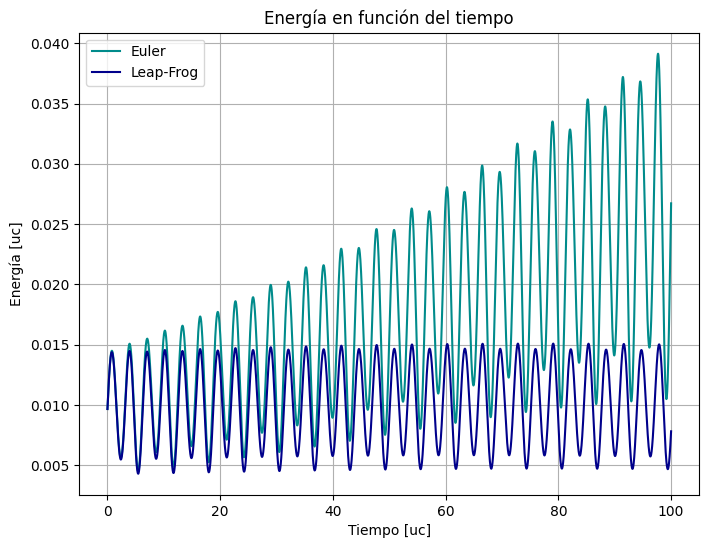

In [36]:
graficar_energia(E_euler, E_lf, dt, n_pasos)

**Conclusión.**

Se observa la evolución de la energía en función del tiempo para los métodos de integración de Euler y Leap-Frog. Se pueden destacar las siguientes observaciones:

- El método de Euler presenta una divergencia significativa en la energía a lo largo del tiempo. Esto se debe a que es un método explícito de primer orden, el cual introduce errores acumulativos y no conserva la estructura hamiltoniana del sistema.
- El método Leap-Frog, en cambio, muestra una mayor estabilidad en la conservación de la energía. Esto se debe a que es un método de integración simplicial, lo que implica que conserva mejor las propiedades del sistema dinámico.
- A pesar de la mejor conservación de la energía en Leap-Frog, se pueden notar pequeñas oscilaciones debido a la naturaleza discreta de la integración numérica. Sin embargo, estas oscilaciones no crecen de manera descontrolada, lo que indica una mejor fidelidad en la simulación del sistema.

Por lo tanto, se concluye que el método Leap-Frog es preferible para la simulación de sistemas hamiltonianos, especialmente en estudios de dinámica a largo plazo.

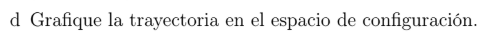

In [37]:
def graficar_trayectoria(x_euler, y_euler, x_lf, y_lf):
    """Gráfica de la trayectoria en el espacio de configuración."""
    plt.figure(figsize=(8, 6))
    plt.plot(x_euler, y_euler, label='Euler', color='Darkcyan')
    plt.plot(x_lf, y_lf, label='Leap-Frog', color='Darkblue')
    plt.xlabel('x [uc]')
    plt.ylabel('y [uc]')
    plt.legend()
    plt.title('Trayectoria en el espacio de fases')
    plt.grid(True)
    plt.show()

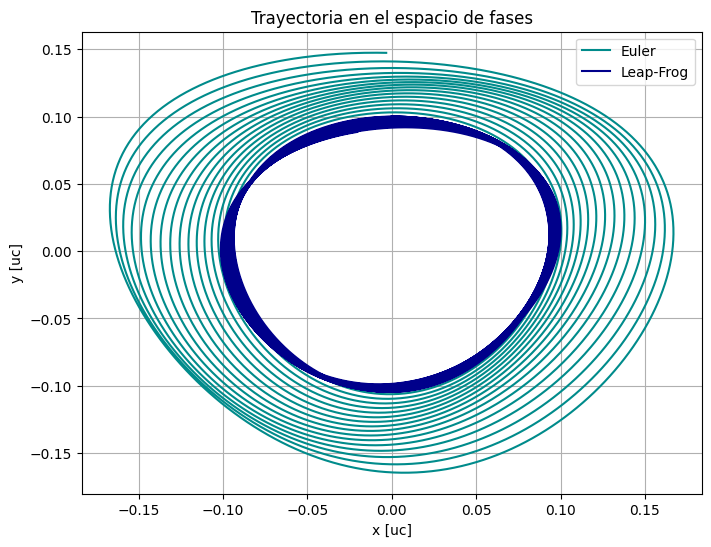

In [38]:
graficar_trayectoria(x_euler, y_euler, x_lf, y_lf)

Se presenta la trayectoria en el espacio de configuración $(x, y)$ obtenida con ambos métodos numéricos. A partir de esta gráfica, se pueden extraer las siguientes conclusiones:

- La trayectoria obtenida con el método de Euler muestra una desviación progresiva, lo que indica una acumulación de errores numéricos en cada paso de integración. Esto resulta en una pérdida de precisión en la evolución del sistema.
- Por otro lado, la trayectoria generada con Leap-Frog se mantiene dentro de una región más estable y parece seguir mejor la dinámica esperada del sistema hamiltoniano.
- Debido a que el sistema de Hénon-Heiles es un sistema no lineal que puede exhibir comportamiento caótico, el uso de un método numérico adecuado es esencial para obtener resultados confiables. El método de Leap-Frog permite estudiar mejor la evolución del sistema sin introducir errores numéricos significativos.

En conclusión, la comparación entre ambos métodos resalta la importancia de elegir un esquema de integración adecuado para sistemas hamiltonianos. Mientras que Euler es simple de implementar, su falta de conservación de la energía lo hace inadecuado para estudios a largo plazo. En contraste, Leap-Frog se muestra como una opción más robusta para la simulación de sistemas conservativos.


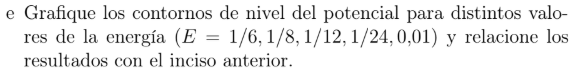

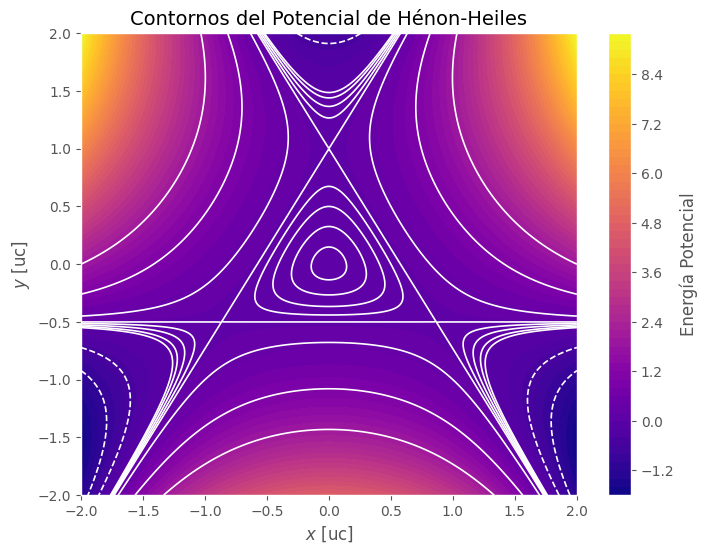

In [42]:
plt.style.use('ggplot')

# Definición del espacio de malla
x = np.linspace(-2, 2, 400)
y = np.linspace(-2, 2, 400)
X, Y = np.meshgrid(x, y)

# Potencial de Hénon-Heiles
Z = 0.5 * (X**2 + Y**2) + X**2 * Y - (1/3) * Y**3

# Creación de la figura
fig, ax = plt.subplots(figsize=(8, 6))

# Contornos de color
cont = ax.contourf(X, Y, Z, levels=60, cmap='plasma')

# Contornos resaltados en blanco para valores específicos de energía
niveles_energia = [-1, -0.5, 0.01, 1/24, 1/12, 1/8, 1/6, 1/3, 1, 2]
ax.contour(X, Y, Z, levels=niveles_energia, colors='w', linewidths=1.2)

# Configuración de etiquetas y formato
ax.set_title('Contornos del Potencial de Hénon-Heiles', fontsize=14)
ax.set_xlabel(r'$x$ [uc]', fontsize=12)
ax.set_ylabel(r'$y$ [uc]', fontsize=12)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

# Barra de colores
cbar = plt.colorbar(cont, ax=ax)
cbar.set_label('Energía Potencial', fontsize=12)

# Mostrar gráfico
plt.show()

**Análisis del Potencial y los Contornos de Nivel**

El potencial del sistema de Hénon-Heiles está dado por:

\begin{equation}
V(x,y) = \frac{1}{2} (x^2 + y^2) + x y - \frac{1}{3} y^3
\end{equation}

Los contornos de nivel del potencial representan las regiones del espacio de configuración $(x, y)$ donde la energía potencial toma valores específicos. Dado que el sistema es conservativo, las trayectorias permitidas por la dinámica están restringidas a regiones donde la energía total $H$ es constante.

**Relación con el Inciso Anterior**

**1. Comparación con la Trayectoria en el Espacio de Fases**

- En el inciso anterior, las trayectorias en el espacio de configuración $(x,y)$ fueron obtenidas mediante integración numérica con los métodos de Euler y Leap-Frog.
- Dichas trayectorias deben coincidir con las líneas de nivel del potencial cuando la energía total es constante.
- Si la energía de las partículas es menor que una energía crítica, las trayectorias estarán confinadas a regiones limitadas del espacio de configuración.

**2. Energía y Comportamiento Dinámico**

- Para valores bajos de $E$, los contornos de nivel muestran regiones cerradas, indicando órbitas cuasi-periódicas.
- A medida que $E$ aumenta, las regiones accesibles en el espacio de configuración se expanden, lo que puede dar lugar a un comportamiento caótico en ciertas condiciones.
- La energía crítica para la transición al caos en el sistema de Hénon-Heiles está alrededor de $E \approx 1/6$. Para valores cercanos, se observa que las trayectorias pueden dejar de ser cerradas y mostrar trayectorias más erráticas.

**3. Regiones Permitidas y Estructura del Potencial**

- En los valores de energía dados ($E = 1/6, 1/8, 1/12, 1/24, 0.01$), los contornos de nivel nos permiten visualizar cómo la partícula puede moverse dentro del potencial.
- Para valores pequeños de $E$, la partícula está confinada a una región central.
- Para $E = 1/6$, el sistema se acerca al umbral de caos, donde pueden aparecer órbitas abiertas o interacciones más complejas entre las regiones del potencial.

**Conclusión**

El estudio de los contornos de nivel del potencial nos permite comprender mejor las trayectorias obtenidas con los métodos de integración numérica. Al comparar los contornos con las trayectorias de Euler y Leap-Frog, se puede verificar que las soluciones numéricas siguen las regiones de energía permitidas por el potencial. Además, se puede analizar la transición del sistema hacia un comportamiento caótico a medida que la energía aumenta.
